<a href="https://www.kaggle.com/code/lalit7881/autism-spectrum-disorder-asd-prediction-100-acc?scriptVersionId=307374829" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/stealthtechnologies/predict-autism-spectrum-disorder-asd/Autism.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/predict-autism-spectrum-disorder-asd/Autism.csv")

In [3]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


In [4]:
df.tail()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
699,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
700,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
701,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
702,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO
703,1,0,1,1,1,0,1,1,1,1,...,f,White-European,no,no,Cyprus,no,8,'18 and more',Self,YES


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethnicity        704 non-null    object
 13  jundice          704 non-null    object
 14  austim           704 non-null    object
 15  contry_of_res    704 non-null    object
 16  used_app_before  704 non-null    object
 17  result           704 non-null    in

In [6]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


In [7]:
df.dtypes

A1_Score            int64
A2_Score            int64
A3_Score            int64
A4_Score            int64
A5_Score            int64
A6_Score            int64
A7_Score            int64
A8_Score            int64
A9_Score            int64
A10_Score           int64
age                object
gender             object
ethnicity          object
jundice            object
austim             object
contry_of_res      object
used_app_before    object
result              int64
age_desc           object
relation           object
Class/ASD          object
dtype: object

In [8]:
df.shape

(704, 21)

In [9]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5)

In [11]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [12]:
df.nunique()

A1_Score            2
A2_Score            2
A3_Score            2
A4_Score            2
A5_Score            2
A6_Score            2
A7_Score            2
A8_Score            2
A9_Score            2
A10_Score           2
age                47
gender              2
ethnicity          12
jundice             2
austim              2
contry_of_res      67
used_app_before     2
result             11
age_desc            1
relation            6
Class/ASD           2
dtype: int64

## EDA

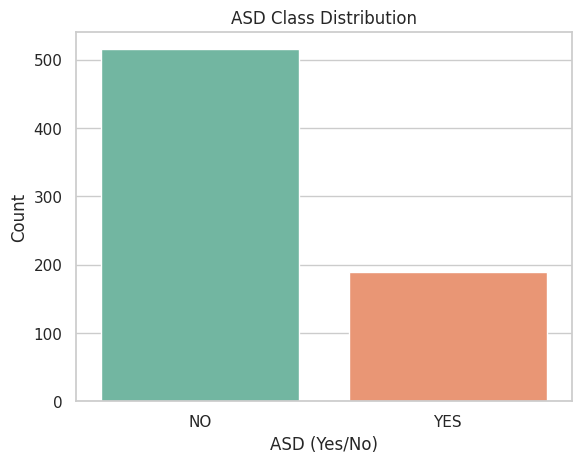

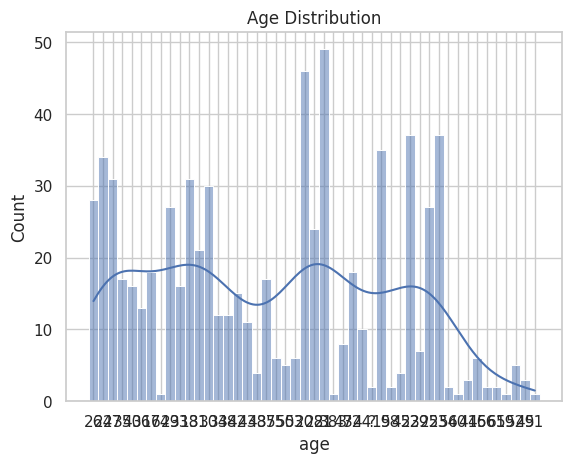

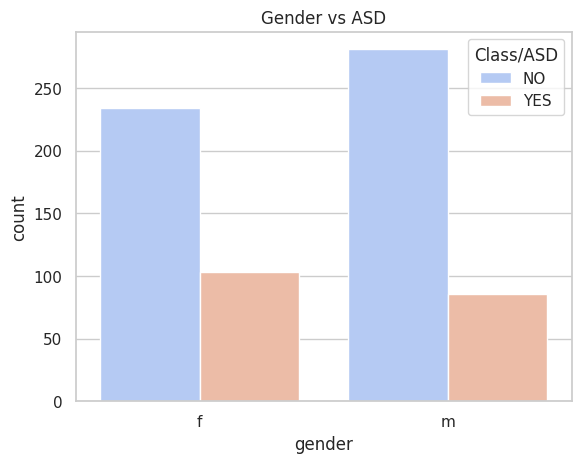

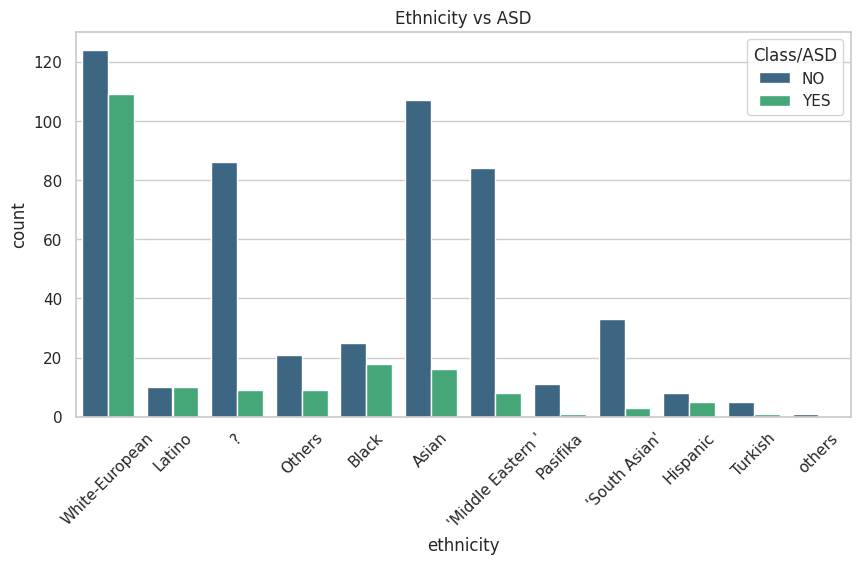

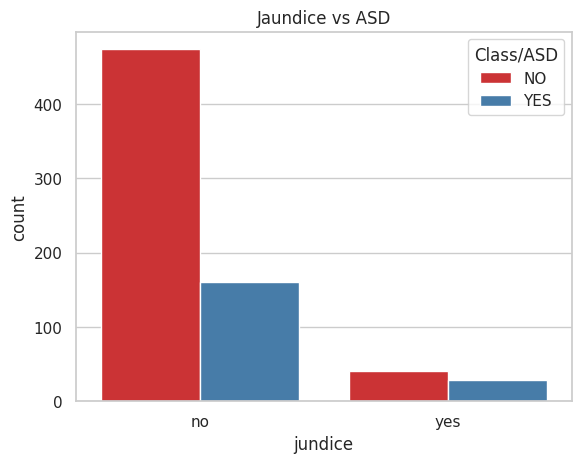

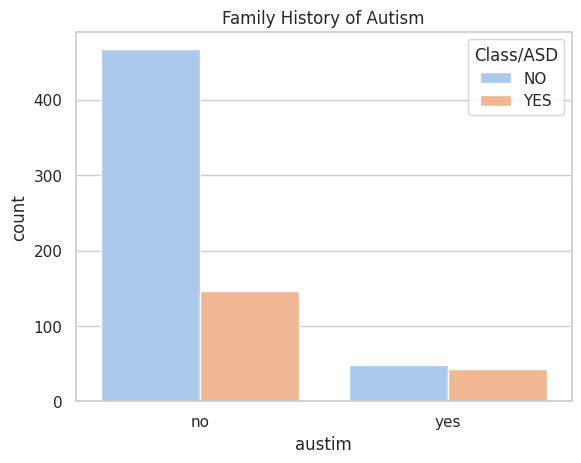

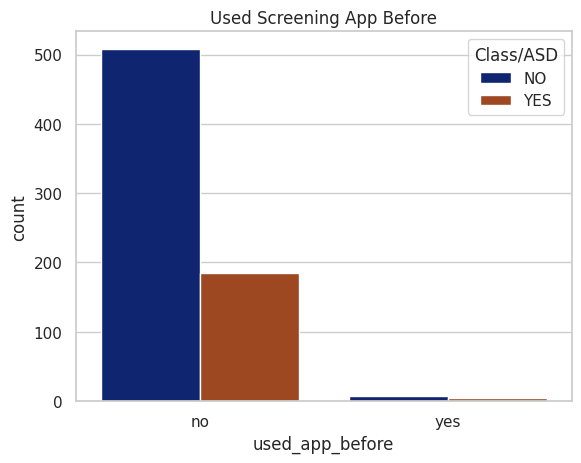

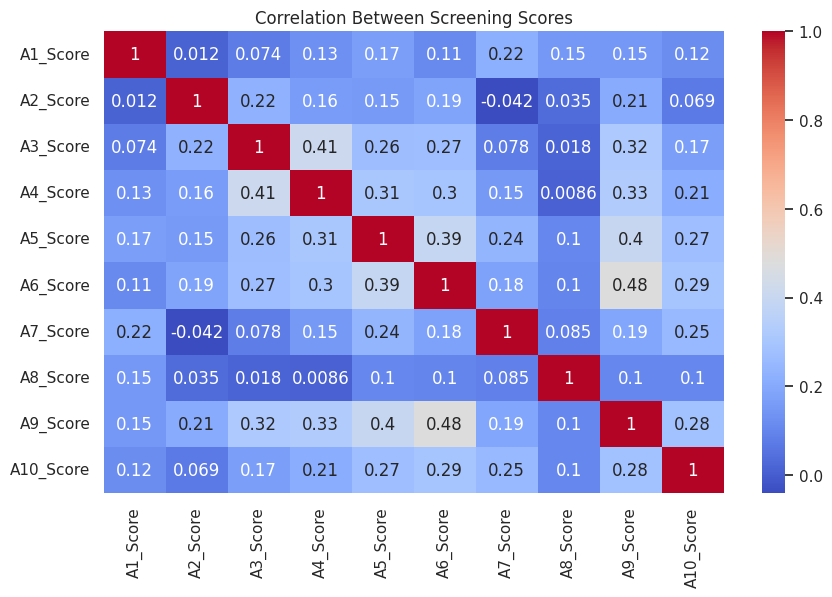

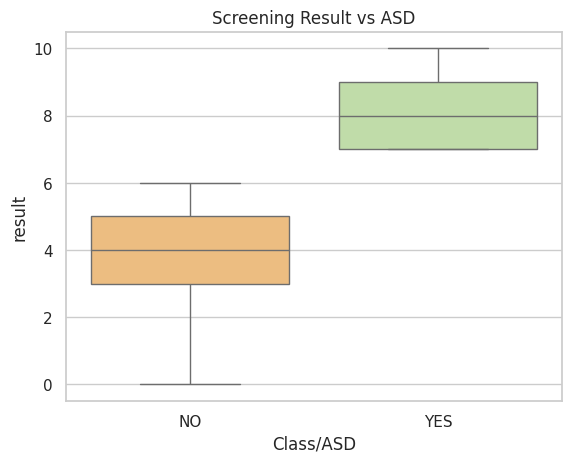

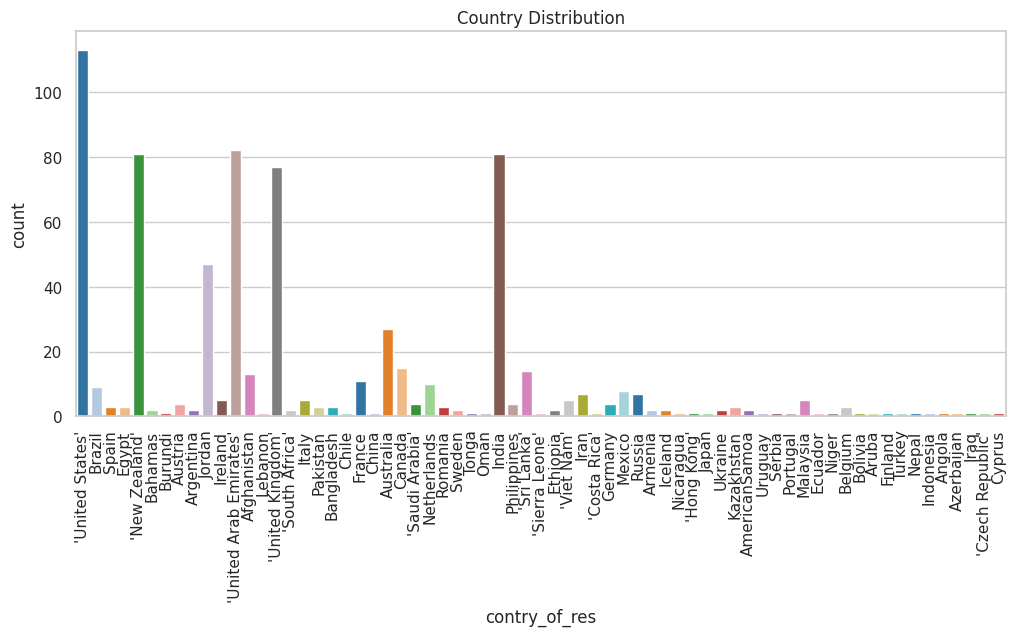

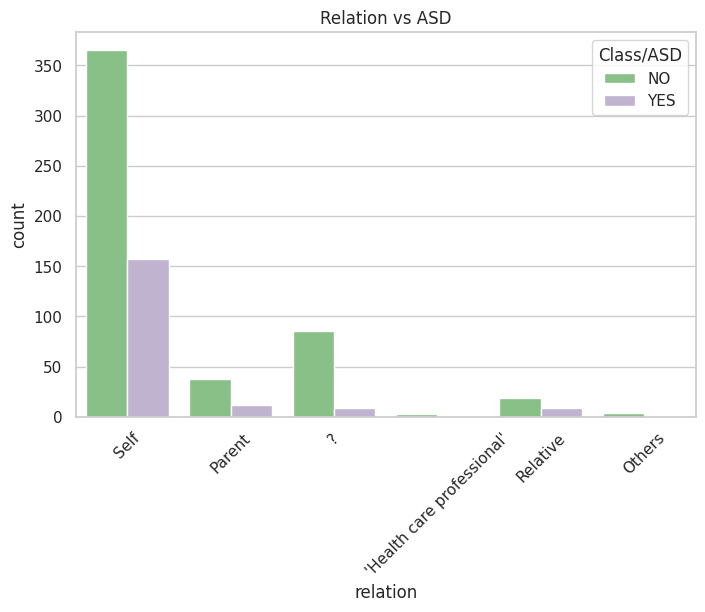

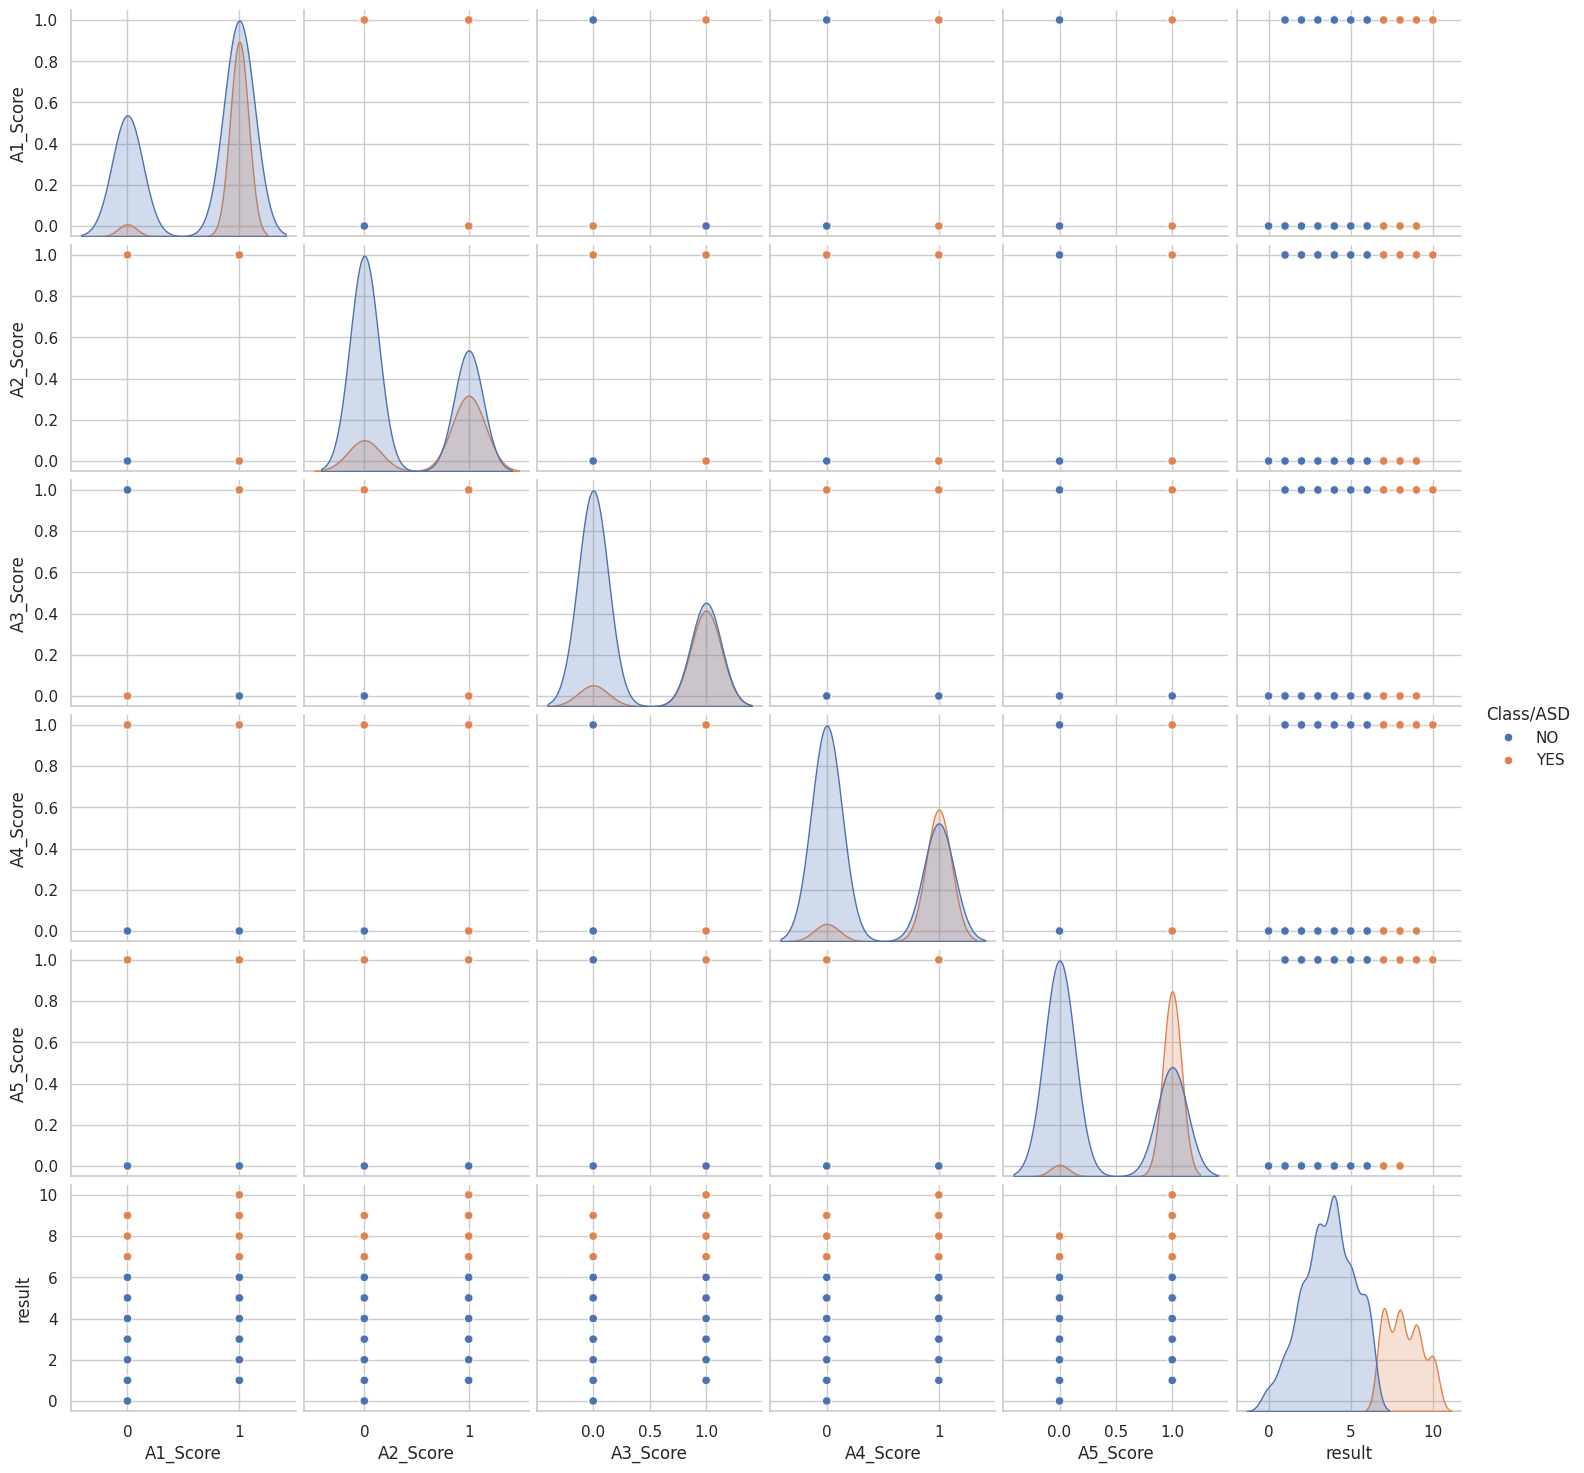

In [13]:
# Set style
sns.set(style="whitegrid")

# -----------------------------
# 1. Target Distribution
# -----------------------------
plt.figure()
sns.countplot(x='Class/ASD', data=df, palette='Set2')
plt.title("ASD Class Distribution")
plt.xlabel("ASD (Yes/No)")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 2. Age Distribution
# -----------------------------
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# -----------------------------
# 3. Gender vs ASD
# -----------------------------
plt.figure()
sns.countplot(x='gender', hue='Class/ASD', data=df, palette='coolwarm')
plt.title("Gender vs ASD")
plt.show()

# -----------------------------
# 4. Ethnicity vs ASD
# -----------------------------
plt.figure(figsize=(10,5))
sns.countplot(x='ethnicity', hue='Class/ASD', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title("Ethnicity vs ASD")
plt.show()

# -----------------------------
# 5. Jaundice vs ASD
# -----------------------------
plt.figure()
sns.countplot(x='jundice', hue='Class/ASD', data=df, palette='Set1')
plt.title("Jaundice vs ASD")
plt.show()

# -----------------------------
# 6. Autism Family History
# -----------------------------
plt.figure()
sns.countplot(x='austim', hue='Class/ASD', data=df, palette='pastel')
plt.title("Family History of Autism")
plt.show()

# -----------------------------
# 7. App Usage Before
# -----------------------------
plt.figure()
sns.countplot(x='used_app_before', hue='Class/ASD', data=df, palette='dark')
plt.title("Used Screening App Before")
plt.show()

# -----------------------------
# 8. Score Features Correlation
# -----------------------------
score_cols = [col for col in df.columns if 'Score' in col]

plt.figure(figsize=(10,6))
sns.heatmap(df[score_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Screening Scores")
plt.show()

# -----------------------------
# 9. Result vs ASD
# -----------------------------
plt.figure()
sns.boxplot(x='Class/ASD', y='result', data=df, palette='Spectral')
plt.title("Screening Result vs ASD")
plt.show()

# -----------------------------
# 10. Country Distribution
# -----------------------------
plt.figure(figsize=(12,5))
sns.countplot(x='contry_of_res', data=df, palette='tab20')
plt.xticks(rotation=90)
plt.title("Country Distribution")
plt.show()

# -----------------------------
# 11. Relation vs ASD
# -----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x='relation', hue='Class/ASD', data=df, palette='Accent')
plt.xticks(rotation=45)
plt.title("Relation vs ASD")
plt.show()

# -----------------------------
# 12. Pairplot (Important Features)
# -----------------------------
important_cols = score_cols[:5] + ['age', 'result', 'Class/ASD']
sns.pairplot(df[important_cols], hue='Class/ASD')
plt.show()

## Feature engineering


Logistic Regression
Accuracy : 0.9929
ROC-AUC  : 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       103
           1       1.00      0.97      0.99        38

    accuracy                           0.99       141
   macro avg       1.00      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141

--------------------------------------------------

Random Forest
Accuracy : 1.0000
ROC-AUC  : 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141

--------------------------------------------------

SVM
Accuracy : 0.9645
ROC-AUC  : 0.9992

Classification Report:
               precis

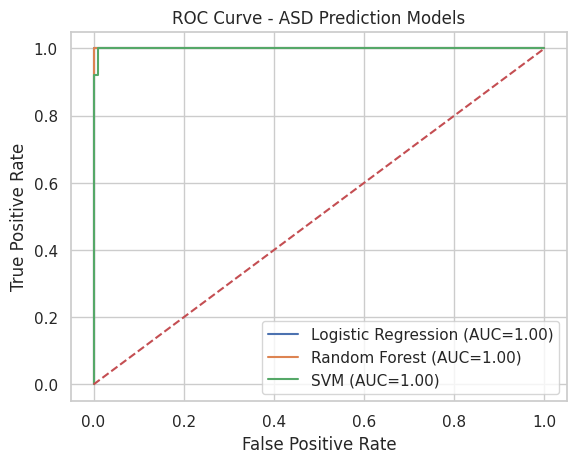

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report


# -----------------------------
# 2. Target Variable
# -----------------------------
target = 'Class/ASD'

# Drop unnecessary columns (optional)
drop_cols = ['age_desc']  # not useful
df = df.drop(columns=drop_cols, errors='ignore')

# -----------------------------
# 3. Features & Target Split
# -----------------------------
X = df.drop(columns=[target])
y = df[target]

# Convert target to binary (if needed)
y = y.map({'YES':1, 'NO':0, 'Yes':1, 'No':0})

# -----------------------------
# 4. Identify Column Types
# -----------------------------
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# -----------------------------
# 5. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 6. Preprocessing Pipeline
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# -----------------------------
# 7. Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

# -----------------------------
# 8. Training + Evaluation
# -----------------------------
plt.figure()

for name, model in models.items():
    
    # Create pipeline (NO DATA LEAKAGE)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("-"*50)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# -----------------------------
# 9. Plot ROC Curve
# -----------------------------
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ASD Prediction Models")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!!